<a href="https://colab.research.google.com/github/harishyaga/TO-DO-list/blob/main/Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="xrQwHTNL26hPQMT29Yz2")
project = rf.workspace("cornell-university-gxjqt").project("chicken-pose-all")
version = project.version(8)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Chicken-pose-all-8 in yolov8:: 100%|██████████| 3434/3434 [00:00<00:00, 4106.48it/s]


In [8]:
# to intall dependencies

!pip install ultralytics opencv-python matplotlib pandas



In [11]:
#these are the required libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO


Total training images: 1


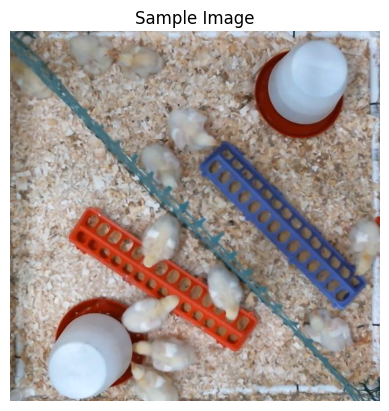

In [14]:
#Loading & Exploring Data
# image files
import glob
images = glob.glob("/content/Chicken-pose-all-8/train/images/101337-2_png.rf.49bb314a5f6dc4bbcbdc006abe80a9dc.jpg")
print("Total training images:", len(images))

# Displaying a sample image
img = cv2.imread(images[0])
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Sample Image")
plt.axis('off')
plt.show()


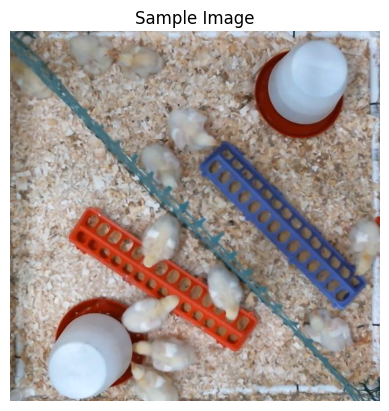

In [15]:
import cv2
import matplotlib.pyplot as plt

if len(images) > 0:
    img = cv2.imread(images[0])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title("Sample Image")
    plt.axis('off')
    plt.show()
else:
    print("No images found. Check your path.")


In [18]:
#Loading YOLOv8 Model

from ultralytics import YOLO

# Loading pre-trained model (nano version - fast & small)
model = YOLO("yolov8n.pt")  # 'n' means nano

# Training the dataset
model.train(data="/content/Chicken-pose-all-8/data.yaml", epochs=5,imgsz=416)


Ultralytics 8.3.159 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Chicken-pose-all-8/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretr

train: Scanning /content/Chicken-pose-all-8/train/labels.cache... 1346 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1346/1346 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 642.4±208.7 MB/s, size: 72.8 KB)



val: Scanning /content/Chicken-pose-all-8/valid/labels.cache... 188 images, 0 backgrounds, 0 corrupt: 100%|██████████| 188/188 [00:00<?, ?it/s]


Plotting labels to runs/detect/train3/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001429, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 416 train, 416 val
Using 0 dataloader workers
Logging results to runs/detect/train3
Starting training for 5 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all        188       2092       0.67      0.853      0.778       0.61



5 epochs completed in 0.711 hours.
Optimizer stripped from runs/detect/train3/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train3/weights/best.pt, 6.2MB

Validating runs/detect/train3/weights/best.pt...
Ultralytics 8.3.159 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:24<00:00,  4.13s/it]


                   all        188       2092       0.67      0.853      0.778       0.61
             eat-drink        169        520      0.815      0.938      0.935      0.707
                moving        169        890      0.617      0.797      0.703       0.55
                  rest        162        682      0.578      0.824      0.697      0.574
Speed: 1.1ms preprocess, 109.3ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to runs/detect/train3


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ab0fedd2f10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [19]:
#Evaluating the Model
results = model.val()
print(results)


Ultralytics 8.3.159 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1479.5±423.7 MB/s, size: 72.2 KB)


val: Scanning /content/Chicken-pose-all-8/valid/labels.cache... 188 images, 0 backgrounds, 0 corrupt: 100%|██████████| 188/188 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 12/12 [00:24<00:00,  2.00s/it]


                   all        188       2092       0.67      0.853      0.778       0.61
             eat-drink        169        520      0.815      0.938      0.935      0.707
                moving        169        890      0.617      0.797      0.703       0.55
                  rest        162        682      0.578      0.824      0.697      0.574
Speed: 1.2ms preprocess, 110.2ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to runs/detect/train32
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ab0eabac0d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,

In [20]:
#Visualizing Predictions
model.predict(source="/content/Chicken-pose-all-8/valid/images", save=True, conf=0.25)



image 1/188 /content/Chicken-pose-all-8/valid/images/100030-1_png.rf.a4a2ea3e5bc6baffe88858c6412185c5.jpg: 416x416 1 eat-drink, 6 movings, 8 rests, 132.7ms
image 2/188 /content/Chicken-pose-all-8/valid/images/100030-3_png.rf.b8f792a37ed219d25f7a1449015a5423.jpg: 416x416 4 movings, 12 rests, 100.2ms
image 3/188 /content/Chicken-pose-all-8/valid/images/100927-1_png.rf.f6b1f59439a4904e73e244393be249c0.jpg: 416x416 3 eat-drinks, 10 movings, 4 rests, 108.2ms
image 4/188 /content/Chicken-pose-all-8/valid/images/100_jpg.rf.e2a93bc4aba6f82b8960ed1b0fe838b0.jpg: 416x416 10 movings, 6 rests, 105.8ms
image 5/188 /content/Chicken-pose-all-8/valid/images/1010_jpg.rf.4c69ec66e318312f72f4f9af2e01ebc6.jpg: 416x416 6 eat-drinks, 7 movings, 1 rest, 109.4ms
image 6/188 /content/Chicken-pose-all-8/valid/images/101337-8_png.rf.8abc63f440dc64ba45a430e2287cddbc.jpg: 416x416 2 eat-drinks, 5 movings, 7 rests, 103.9ms
image 7/188 /content/Chicken-pose-all-8/valid/images/102125-4-_png.rf.dbc606b2be181de4385b0e4

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'eat-drink', 1: 'moving', 2: 'rest'}
 obb: None
 orig_img: array([[[ 79,  82,  56],
         [ 80,  83,  58],
         [ 80,  82,  60],
         ...,
         [139, 142, 180],
         [139, 141, 181],
         [138, 142, 183]],
 
        [[ 91,  93,  64],
         [ 92,  93,  67],
         [ 94,  93,  72],
         ...,
         [137, 138, 176],
         [135, 137, 177],
         [133, 137, 178]],
 
        [[ 98,  98,  68],
         [100, 100,  70],
         [106, 105,  79],
         ...,
         [134, 135, 173],
         [131, 133, 173],
         [130, 132, 172]],
 
        ...,
 
        [[152, 158, 147],
         [152, 160, 150],
         [154, 161, 154],
         ...,
         [  0,   4,   3],
         [  0,   0,   1],
         [  0,   0,   1]],
 
        [[142, 150, 139],
         [145, 153, 143],
         [149, 156, 149],
     

In [27]:
# Weight Estimation
'''
    x: X-coordinate of the center of the bounding box

    y: Y-coordinate of the center

    w: Width of the bounding box

    h: Height of the bounding box
'''
weight_scale = 0.05  #  own logic
def estimate_weight_from_bbox(xywh):
    area = xywh[2] * xywh[3]  # width * height
    return area * weight_scale






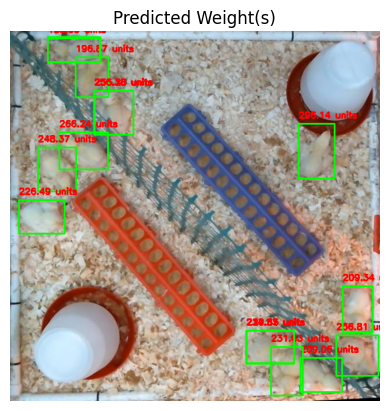

In [31]:
import cv2
img_path = "/content/Chicken-pose-all-8/valid/images/100030-1_png.rf.a4a2ea3e5bc6baffe88858c6412185c5.jpg"
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Draw boxes and weights
for result in results:
    boxes = result.boxes.xywh.cpu().numpy()
    for box in boxes:
        x_center, y_center, w, h = box
        estimated_weight = estimate_weight_from_bbox(box)

        # Convert center x/y to top-left for drawing
        x1 = int(x_center - w/2)
        y1 = int(y_center - h/2)
        x2 = int(x_center + w/2)
        y2 = int(y_center + h/2)

        cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)
        cv2.putText(img, f"{estimated_weight:.2f} units", (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 2)

plt.imshow(img)
plt.axis('off')
plt.title("Predicted Weight(s)")
plt.show()


In [32]:
results = model.val()


Ultralytics 8.3.159 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 903.5±385.8 MB/s, size: 72.3 KB)


val: Scanning /content/Chicken-pose-all-8/valid/labels.cache... 188 images, 0 backgrounds, 0 corrupt: 100%|██████████| 188/188 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 12/12 [00:24<00:00,  2.01s/it]


                   all        188       2092       0.67      0.853      0.778       0.61
             eat-drink        169        520      0.815      0.938      0.935      0.707
                moving        169        890      0.617      0.797      0.703       0.55
                  rest        162        682      0.578      0.824      0.697      0.574
Speed: 1.2ms preprocess, 112.2ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to runs/detect/train34


In [38]:
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

# YOLO saves training results in content/runs/detect/train
train_dir = Path("/content/runs/detect/train")
results_image = train_dir/ "results.png"

if results_image.exists():
    img = Image.open(results_image)
    plt.imshow(img)
    plt.axis('off')
    plt.title("Training Metrics")
    plt.show()


In [42]:
#Simulating Weights and Plot:
predictions = model.predict(source="/content/Chicken-pose-all-8/train/images", save=False)

estimated_weights = []
image_names = []

for result in predictions:
    image_name = os.path.basename(result.path)
    image_names.append(image_name)

    # Use first detected box only for simplicity
    if len(result.boxes.xywh) > 0:
        box = result.boxes.xywh[0].cpu().numpy()  # [x, y, w, h]
        area = box[2] * box[3]
        estimated_weight = area * 0.05  # scale factor (adjust as needed)
        estimated_weights.append(estimated_weight)
    else:
        estimated_weights.append(0)



WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1346 /content/Chicken-pose-all-8/train/images/100030-4_png.rf.50e6f8aaf5c7c63a25c4c5ecdea3e3d9.jpg: 416x416 5 eat-drinks, 6 movings, 2 rests, 111.5ms
image 2/1346 /content/Chicken-pose-all-8/train/images/1000_jpg.rf.11d830f32e842cef43e8d5d1c72f2b38.jpg: 416x416 5 eat-drinks, 10 movings, 3 rests, 104.5ms
image 3/1346 /content/Chicken-pose-all-8/train/images/1001_jpg.rf.ef0ad44ed889ad589f629949960304af.jpg: 416x416 8 movings, 11 rests, 103.6ms
im

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.


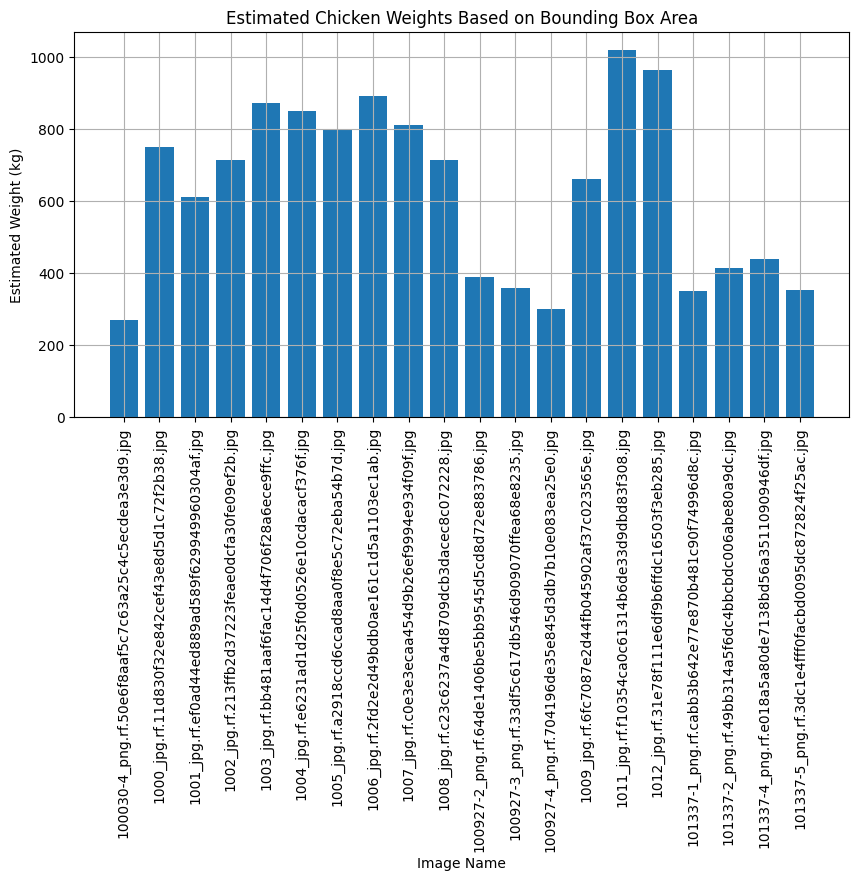

In [43]:
#Estimated Weights

plt.figure(figsize=(10, 5))
plt.bar(image_names[:20], estimated_weights[:20])
plt.xticks(rotation=90)
plt.xlabel("Image Name")
plt.ylabel("Estimated Weight (kg)")
plt.title("Estimated Chicken Weights Based on Bounding Box Area")
plt.grid(True)
plt.tight_layout()
plt.show()


Full Name     :HARIPRASAD SHYAGA

Email Address :hariprasadshyaga95@gmail.com

Phone Number  :+91 8522004642

LinkedIn      :https://www.linkedin.com/in/hariprasad-shyaga-550676246/

GitHub link   :https://github.com/harishyaga